# Computer Exercise 15.33 — Problem 3
## 크기인가 배분인가 — $\sigma$ 의 평균을 고정하고 이질성만 남긴다

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.33
> **단원**: Ch 15 Sequential Decision Making — §15.33 Magnitude versus Allocation
> **풀이 일자**: 2026-08-18 (Day 100)
> **언어**: Python 3.10 · NumPy / pandas / SciPy / Matplotlib
>
> Day 99 P2 의 3 성분 분해는 이렇게 끝났다: 잡음 도입 $-0.1596$, $\sigma$ 스케일 $+0.2124$,
> $\sigma$ **이질성** $-0.1804$. 결론은 한 문장이었다 —
> **"학습된 $\sigma$ 는 크기는 맞추고 배분을 틀린다"** ($\mathrm{cv} = 0.86$).
>
> 그러나 그 분해는 **관찰적**이다. `cnrt` 와 `fix_big` 은 크기와 배분이 **동시에** 다르므로,
> 두 성질 중 어느 것이 손해를 내는지 두 arm 비교로는 지목할 수 없다. Problem 3 은 개입한다.
> $\sigma$ 를 학습하되 **평균을 $0.55$ 로 강제**하면 크기가 통제되고 이질성만 남는다.
> 학습된 $\sigma$ 를 좌표에 대해 **무작위로 섞으면** 이질성의 양은 같되 학습된 구조가 사라진다.
> 세 arm 이 같은 평균 크기를 갖고 **배분만** 다르게 된다.

## 1. 문제 (원문)

> **Computer Exercise 15.33.3.** Exercise 15.32 decomposed the effect of a learned noise scale into
> a magnitude component and a heterogeneity component and concluded, observationally, that the
> learned $\sigma$ "gets the magnitude right and the allocation wrong" ($\mathrm{cv} = 0.86$).
> Test this interventionally. Construct three arms that share the same mean noise magnitude
> $\bar\sigma = 0.55$ but differ only in how that magnitude is allocated across the coordinates of
> the noisy head: (i) **uniform** ($\sigma \equiv 0.55$), (ii) **learned allocation under a mean
> constraint** ($\sigma \leftarrow \sigma\,\bar\sigma_{\text{target}}/\bar\sigma$ after every
> update), and (iii) **random allocation** (the terminal $\sigma$ of the unconstrained learner,
> permuted across coordinates and rescaled to the same mean). Add a magnitude control
> ($\sigma \equiv 0.125$) and the unconstrained learner. Pre-register a family of four comparisons,
> run the mandated A/A check, and adjudicate under the calibrated protocol of Exercise 15.33.1.
> Report the terminal coefficient of variation of $\sigma$ for every arm, and state whether
> heterogeneity is harmful *per se* or only in combination with magnitude.

### 한국어 풀이용 정리

설계는 **크기 $\times$ 배분** 의 요인 설계다.

| arm | $\bar\sigma$ | 배분 | 역할 |
|---|---|---|---|
| `base` | — | — | 기준선 ($\varepsilon$-greedy) |
| `fix_small` | $0.125$ | 균일 | 크기 통제 (작은 쪽) |
| **`fix_big`** | $0.55$ | **균일** | Day 99 의 승자 · 배분 비교의 기준 |
| **`fix_het`** | $0.55$ | **무작위** (학습된 $\sigma$ 를 좌표에 대해 치환) | 이질성의 *양*만 이식 |
| **`cnrt_mc`** | $0.55$ (강제) | **학습** | 이질성의 *구조*까지 |
| `cnrt` | 자유 (학습) | 학습 | Day 90–99 의 $+$CNRT |

가운데 세 arm 은 **평균 크기가 같다**. 따라서 그들 사이의 차이는 전부 배분에서 온다.
이것이 관찰적 분해와 결정적으로 다른 점이다.

세 가지 답이 가능하고, 각각 다른 것을 함의한다.

- **(A) 이질성 자체가 해롭다** — `fix_big` $>$ `fix_het` $\approx$ `cnrt_mc`.
  잡음은 균일해야 하며, $\sigma$ 를 학습하는 것은 자유도 낭비다.
- **(B) 학습된 배분이 특별히 나쁘다** — `fix_big` $\approx$ `fix_het` $>$ `cnrt_mc`.
  TD 기울기가 $\sigma$ 를 **체계적으로 잘못된 방향**으로 민다.
- **(C) 배분은 중요하지 않다** — 셋이 모두 비슷하다. Day 99 의 $-0.1804$ 는
  크기와 교락된 것이었다.

## 2. 수학적 배경

### 2.1 평균 고정 제약

Factorized Noisy Linear 헤드의 잡음 스케일을 $\sigma \in \mathbb R^{d}$ ($d = |W_\sigma| + |b_\sigma|$)
라 하자. 자유 학습은 TD 손실의 기울기

$$\frac{\partial\mathcal L}{\partial\sigma_j} = \frac{\partial\mathcal L}{\partial W^{\text{eff}}_j}\,\varepsilon_j$$

를 따르며, 크기 $\bar\sigma = d^{-1}\sum_j \sigma_j$ 와 배분
$\hat\sigma = \sigma/\bar\sigma$ 를 **동시에** 움직인다. 매 갱신 뒤 사영

$$\boxed{\;\sigma \;\longleftarrow\; \sigma \cdot \frac{\bar\sigma_{\text{target}}}{\bar\sigma}\;}$$

를 걸면 $\bar\sigma$ 는 상수로 고정되고 기울기의 **방향 성분만** 남는다. 이것은
$\{\sigma : \bar\sigma = \bar\sigma_{\text{target}},\ \sigma > 0\}$ 위로의 사영이며,
갱신은 그 초평면에 접한 성분만 살린다. 즉 **크기 채널을 닫고 배분 채널만 연다.**

### 2.2 이질성의 측정

배분의 불균등성은 변동계수로 잰다:

$$\mathrm{cv}(\sigma) = \frac{1}{\bar\sigma}\Big[\frac{1}{d}\sum_j (\sigma_j - \bar\sigma)^2\Big]^{1/2}.$$

$\mathrm{cv} = 0$ 이 균일, Day 99 가 학습된 $\sigma$ 에서 관측한 값이 $0.86$ 이다.
`fix_het` 은 $\mathrm{cv}$ 를 `cnrt` 와 같게 맞추되 **좌표 대응을 파괴**한다:
$\sigma^{\text{het}} = \Pi\sigma^{\text{cnrt}} \cdot \bar\sigma_{\text{target}}/\bar\sigma^{\text{cnrt}}$,
$\Pi$ 는 무작위 치환. 따라서 `fix_het` 과 `cnrt_mc` 는 **같은 크기·같은 이질성 수준**을 갖고
오직 그 이질성이 **어느 좌표에 놓이는가**만 다르다.

### 2.3 유효 교란의 분산

주입되는 유효 가중치 교란은 $\Delta W_j = \sigma_j \varepsilon_j$ 이고
$\varepsilon_j$ 는 평균 0, 분산 $\tau^2$ 로 동일 분포이므로

$$\mathbb E\|\Delta W\|^2 = \tau^2 \sum_j \sigma_j^2 = \tau^2 d\,\bar\sigma^2\big(1 + \mathrm{cv}^2\big).$$

$$\boxed{\;\text{평균을 고정해도 } \mathrm{cv} > 0 \text{ 이면 총 교란 에너지는 } (1+\mathrm{cv}^2)\ \text{배 커진다.}\;}$$

$\mathrm{cv} = 0.86$ 이면 $1.74$ 배다. 이것은 **혼입 요인**이다 — "이질적" arm 은
평균이 같아도 실제로는 더 센 잡음을 받는다. 따라서 아래 [진단] 셀에서 $\bar\sigma$ 뿐 아니라
$\sqrt{\overline{\sigma^2}}$ (제곱평균제곱근) 도 함께 보고하고, 해석에서 이 교락을 명시한다.

### 2.4 사전 명시 가족 ($m = 4$)

$$\mathcal F = \big\{\,
e_1 = \mu_{\texttt{fix\_big}} - \mu_{\texttt{cnrt\_mc}},\;
e_2 = \mu_{\texttt{fix\_big}} - \mu_{\texttt{fix\_het}},\;
e_3 = \mu_{\texttt{fix\_het}} - \mu_{\texttt{cnrt\_mc}},\;
e_4 = \mu_{\texttt{fix\_big}} - \mu_{\texttt{fix\_small}} \,\big\}$$

$e_1,e_2,e_3$ 은 **크기가 통제된** 배분 비교이고, $e_4$ 는 배분이 통제된 (둘 다 균일)
크기 비교다. 1 차 규칙은 부호뒤집기 순열검정, Holm ($m=4$), $\alpha = 0.05$ —
모두 Problem 1 의 프로토콜 v2.

## 3. 풀이 흐름

1. **사전 명시** — 가설·가족·규칙·$n$ 을 자료 생성 전에 못박는다.
2. **`cnrt` 학습** — 시드 $\{100401,\dots,100440\}$ (40 개, P1·P2 와 비중첩) 에서 자유 학습.
   종료 $\sigma$ 를 저장한다 (`fix_het` 의 재료).
3. **`fix_het` 구성** — 각 시드의 종료 $\sigma$ 를 좌표에 대해 치환하고 평균을 $0.55$ 로
   재정규화해 동결 패턴으로 주입.
4. **나머지 arm 학습** — `base`, `fix_small`, `fix_big`, `cnrt_mc` (평균 고정 제약).
5. **제약 검증** — `cnrt_mc` 의 $\bar\sigma$ 가 실제로 $0.55$ 에 고정되었는지, `fix_het` 의
   $\mathrm{cv}$ 가 `cnrt` 와 일치하는지 assert. 실패하면 개입이 성립하지 않으므로 정지.
6. **A/A 점검** (v2 필수).
7. **판정** — 가족 $\mathcal F$ 에 순열 $p$ + Holm + 검정 반전 CI + $n^\star$.
8. **진단 지표** — arm 별 $\bar\sigma$, $\mathrm{cv}$, $\sqrt{\overline{\sigma^2}}$,
   회복률, 미끼 고착률. $\sigma$ 궤적.
9. **그림** — (Fig 1) 크기 $\times$ 배분 지형과 $\sigma$ 궤적. (Fig 2) forest plot + cv 대 return.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t as tdist

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–99 과 동일 계열의 5-상태 chain MDP 재구성) ──────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)          # 0.125 — Noisy 헤드 sigma 의 초기값
SIG_BIG  = 0.55                          # Day 99 P2 의 fix_big (학습 종점에 맞춘 값)

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a                      # slip
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

ARM_SPEC = {           # explore_noise, learn_sigma, inject_noise
    "base":  (False, False, False),
    "cnrt":  (True,  True,  True),
    "fixed": (True,  False, True),
    "inert": (False, False, False),
}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head. Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_decay=0.0, anneal=False, h=H,
                 sigma_init=None, sigma_pattern=None, mean_target=None):
        self.h, self.arm = h, arm
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.sigma_decay, self.anneal, self.scale = sigma_decay, anneal, 1.0
        self.mean_target = mean_target        # None 이면 제약 없음 (자유 학습)
        # 초기화 난수 소비 순서는 arm 과 무관 -> 모든 arm 이 같은 초기 가중치
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, h), sigma_init)
        self.bs = np.full(NA, sigma_init)
        if sigma_pattern is not None:         # 좌표별 sigma 를 외부에서 지정 (fix_het)
            self.Ws = sigma_pattern[0].copy(); self.bs = sigma_pattern[1].copy()
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def sigma_mean(self):
        return (self.Ws.sum() + self.bs.sum()) / (self.Ws.size + self.bs.size)

    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))   # factorized noise
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:
            self.Ws -= ETA * (gW2 * self.eps_W * self.scale + self.sigma_decay * self.Ws)
            self.bs -= ETA * (gb2 * self.eps_b * self.scale + self.sigma_decay * self.bs)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)
            if self.mean_target is not None:      # ★ 평균 고정 제약 (배분만 학습)
                m = self.sigma_mean()
                if m > 1e-12:
                    r = self.mean_target / m
                    self.Ws *= r; self.bs *= r

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_decay=0.0, anneal=False,
          sigma_init=None, sigma_pattern=None, mean_target=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_decay=sigma_decay, anneal=anneal,
                 sigma_init=sigma_init, sigma_pattern=sigma_pattern, mean_target=mean_target)
    lr.trace = []
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if lr.anneal: lr.scale = 1.0 - t / T
        if lr.explore_noise:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, float(lr.sigma_mean())))
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

# ── 프로토콜 상수 ─────────────────────────────────────────────────────────
T_FIXED = 10_000
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
ALPHA = 0.05

# ── 판정 규칙 4 종 ────────────────────────────────────────────────────────
def boot_mean(d, B, rng):
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return d[idx].mean(axis=1)

def ci_percentile(d, B=20_000, seed=0, alpha=ALPHA, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    bs = boot_mean(d, B, rng)
    return tuple(np.percentile(bs, [100*alpha/2, 100*(1-alpha/2)]))

def ci_bca(d, B=20_000, seed=0, alpha=ALPHA, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    n = len(d); th = d.mean(); bs = boot_mean(d, B, rng)
    z0 = norm.ppf(np.clip((bs < th).mean(), 1e-6, 1 - 1e-6))
    jk = (d.sum() - d) / (n - 1); u = jk.mean() - jk
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = np.sum(u**3) / den if den > 1e-300 else 0.0
    def adj(z):
        v = z0 + (z0 + z) / (1 - a * (z0 + z))
        return float(np.clip(norm.cdf(v) * 100, 0.0, 100.0))
    return tuple(np.percentile(bs, [adj(norm.ppf(alpha/2)), adj(norm.ppf(1-alpha/2))]))

def signflip_p(d, B=20_000, seed=1, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    obs = abs(d.mean())
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    null = np.abs((sg * d).mean(axis=1))
    return (1 + (null >= obs - 1e-15).sum()) / (B + 1)

def ttest_p(d):
    n = len(d); s = d.std(ddof=1)
    if s < 1e-15: return 1.0
    tv = d.mean() / (s / np.sqrt(n))
    return float(2 * tdist.sf(abs(tv), n - 1))

def holm(pvals, alpha=ALPHA):
    m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * pvals[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

def n_star(d, power_c=2.8):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((power_c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, c-hw), min(1.0, c+hw))

print(f"chain MDP: states={NS} actions={NA} ep_len={L} | gamma={GAMMA} lr={ETA} H={H} lure={R_LOCAL}")
print(f"sigma 초기값 = {SIG_INIT:.4f}   fix_big sigma = {SIG_BIG}")
print("판정 규칙 4 종 로드: percentile-CI / BCa-CI / sign-flip / paired-t   (+ Holm)")


chain MDP: states=5 actions=2 ep_len=20 | gamma=0.95 lr=0.05 H=16 lure=0.25
sigma 초기값 = 0.1250   fix_big sigma = 0.55
판정 규칙 4 종 로드: percentile-CI / BCa-CI / sign-flip / paired-t   (+ Holm)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [사전 명시 — PRE-REGISTRATION]   자료 생성 전에 실행
# ══════════════════════════════════════════════════════════════════════════
PRE = {
 "질문": "sigma 의 이질성(배분)은 그 자체로 해로운가, 크기와 결합했을 때만 해로운가",
 "개입": "평균 고정 제약 (sigma <- sigma * 0.55 / mean(sigma)) 과 좌표 치환",
 "1차 가족 (m=4, 순서 고정)": [
   "e1 = fix_big  - cnrt_mc    <- 균일 대 학습된 배분 (크기 동일)",
   "e2 = fix_big  - fix_het    <- 균일 대 무작위 배분 (크기 동일)",
   "e3 = fix_het  - cnrt_mc    <- 무작위 대 학습된 배분 (크기·이질성 동일)",
   "e4 = fix_big  - fix_small  <- 크기 효과 (배분 동일: 둘 다 균일)",
 ],
 "1차 판정 규칙": "부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4)  [프로토콜 v2]",
 "표본 크기": "n=40 신규 독립 시드 100401–100440 (v2 최소 30 초과)",
 "사전 예측": "Day 99 P2 의 관찰적 분해가 옳다면 e1>0, e3<0 (학습된 배분이 특히 나쁨)",
 "혼입 요인 (사전 인지)": "cv>0 이면 평균이 같아도 총 교란 에너지가 (1+cv^2) 배 -> 2.3 참조",
 "중지 규칙": "n=40 을 다 쓰고 한 번만 판정한다.",
}
print("═"*74); print("PRE-REGISTRATION  (Day 100 §15.33 P3)"); print("═"*74)
for k, v in PRE.items():
    if isinstance(v, list): print(f"{k}:"); [print(f"    - {x}") for x in v]
    else: print(f"{k}: {v}")
print("═"*74)
SEEDS3 = list(range(100401, 100441)); N3 = len(SEEDS3)
ALPHA_F, B_MAIN, SIG_T = 0.05, 20_000, SIG_BIG

══════════════════════════════════════════════════════════════════════════
PRE-REGISTRATION  (Day 100 §15.33 P3)
══════════════════════════════════════════════════════════════════════════
질문: sigma 의 이질성(배분)은 그 자체로 해로운가, 크기와 결합했을 때만 해로운가
개입: 평균 고정 제약 (sigma <- sigma * 0.55 / mean(sigma)) 과 좌표 치환
1차 가족 (m=4, 순서 고정):
    - e1 = fix_big  - cnrt_mc    <- 균일 대 학습된 배분 (크기 동일)
    - e2 = fix_big  - fix_het    <- 균일 대 무작위 배분 (크기 동일)
    - e3 = fix_het  - cnrt_mc    <- 무작위 대 학습된 배분 (크기·이질성 동일)
    - e4 = fix_big  - fix_small  <- 크기 효과 (배분 동일: 둘 다 균일)
1차 판정 규칙: 부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4)  [프로토콜 v2]
표본 크기: n=40 신규 독립 시드 100401–100440 (v2 최소 30 초과)
사전 예측: Day 99 P2 의 관찰적 분해가 옳다면 e1>0, e3<0 (학습된 배분이 특히 나쁨)
혼입 요인 (사전 인지): cv>0 이면 평균이 같아도 총 교란 에너지가 (1+cv^2) 배 -> 2.3 참조
중지 규칙: n=40 을 다 쓰고 한 번만 판정한다.
══════════════════════════════════════════════════════════════════════════


In [3]:
# ── [1] cnrt 학습 (자유) 과 fix_het 패턴 구성 ───────────────────────────
import time
t0 = time.time()
cnrt_ls = [train(s, T_FIXED, arm="cnrt", trace_every=250) for s in SEEDS3]

def het_pattern(lr, seed):
    """종료 sigma 를 좌표에 대해 치환하고 평균을 SIG_T 로 재정규화."""
    rng = np.random.default_rng(500000 + seed)
    flat = np.concatenate([lr.Ws.ravel(), lr.bs.ravel()])
    flat = rng.permutation(flat)
    flat = flat * (SIG_T / flat.mean())
    nW = lr.Ws.size
    return flat[:nW].reshape(lr.Ws.shape), flat[nW:].reshape(lr.bs.shape)

PATS = {s: het_pattern(l, s) for s, l in zip(SEEDS3, cnrt_ls)}
print(f"cnrt {N3} 시드 학습 + het 패턴 구성  ({time.time()-t0:.1f} s)")
print(f"  cnrt 종료 sigma : mean={np.mean([l.sigma_mean() for l in cnrt_ls]):.4f}")

cnrt 40 시드 학습 + het 패턴 구성  (17.4 s)
  cnrt 종료 sigma : mean=0.5835


In [4]:
# ── [2] 나머지 arm 학습 ─────────────────────────────────────────────────
def cv_of(lr):
    f = np.concatenate([lr.Ws.ravel(), lr.bs.ravel()]);  return f.std() / f.mean()
def rms_of(lr):
    f = np.concatenate([lr.Ws.ravel(), lr.bs.ravel()]);  return np.sqrt((f**2).mean())

t0 = time.time(); LS = {"cnrt": cnrt_ls}
LS["base"]      = [train(s, T_FIXED, arm="base") for s in SEEDS3]
LS["fix_small"] = [train(s, T_FIXED, arm="fixed", sigma_init=SIG_INIT) for s in SEEDS3]
LS["fix_big"]   = [train(s, T_FIXED, arm="fixed", sigma_init=SIG_T) for s in SEEDS3]
LS["fix_het"]   = [train(s, T_FIXED, arm="fixed", sigma_pattern=PATS[s]) for s in SEEDS3]
LS["cnrt_mc"]   = [train(s, T_FIXED, arm="cnrt", sigma_init=SIG_T, mean_target=SIG_T,
                         trace_every=250) for s in SEEDS3]
ORDER = ["base", "fix_small", "fix_big", "fix_het", "cnrt_mc", "cnrt"]

R3, POL3 = {}, {}
for nm in ORDER:
    R3[nm]  = np.array([deploy(l, P_DEPLOY, N_EP, 820000 + i) for i, l in enumerate(LS[nm])])
    POL3[nm] = [greedy_policy(l) for l in LS[nm]]
print(f"6 arm x {N3} 시드 x T={T_FIXED}  ({time.time()-t0:.1f} s)")

6 arm x 40 시드 x T=10000  (68.5 s)


In [5]:
# ── [3] 개입 검증: 제약이 실제로 걸렸는가 ───────────────────────────────
diag = []
for nm in ORDER:
    sm  = np.array([l.sigma_mean() for l in LS[nm]])
    cv  = np.array([cv_of(l) for l in LS[nm]])
    rms = np.array([rms_of(l) for l in LS[nm]])
    rec = np.mean([p == PI_STAR for p in POL3[nm]])
    lure = np.mean([p[0] == 0 for p in POL3[nm]])       # 상태 0 에서 미끼 쪽을 고름
    noisy = ARM_SPEC[LS[nm][0].arm][2]
    diag.append(dict(arm=nm, R=R3[nm].mean(), sd=R3[nm].std(ddof=1),
                     sigma_mean=(sm.mean() if noisy else np.nan),
                     cv=(cv.mean() if noisy else np.nan),
                     rms_sigma=(rms.mean() if noisy else np.nan),
                     recovery=rec, lure_stuck=lure))
dg = pd.DataFrame(diag).set_index("arm")
print("[표 1] arm 별 진단 (sigma 통계는 잡음을 주입하는 arm 에 대해서만)")
print(dg.round(4).to_string())

mc_mean = np.array([l.sigma_mean() for l in LS["cnrt_mc"]])
het_cv  = np.array([cv_of(l) for l in LS["fix_het"]])
cnrt_cv = np.array([cv_of(l) for l in LS["cnrt"]])
print(f"\n[검증] 평균 고정 제약 : cnrt_mc 의 sigma 평균 = {mc_mean.mean():.6f} "
      f"(목표 {SIG_T}, 최대 편차 {np.abs(mc_mean-SIG_T).max():.2e})")
print(f"[검증] 이질성 이식     : fix_het cv = {het_cv.mean():.4f}  vs  cnrt cv = {cnrt_cv.mean():.4f}"
      f"  (상대 편차 {abs(het_cv.mean()-cnrt_cv.mean())/cnrt_cv.mean():.1%})")
assert np.allclose(mc_mean, SIG_T, atol=1e-6), "평균 고정 제약 실패"
assert abs(het_cv.mean()-cnrt_cv.mean())/cnrt_cv.mean() < 0.02, "이질성 이식 실패"
print("  => 개입 성립. 세 arm (fix_big / fix_het / cnrt_mc) 은 평균 크기가 동일하다.")
print(f"  ※ 단, 2.3 의 교락: rms(sigma) 는 fix_big {dg.loc['fix_big','rms_sigma']:.4f} vs "
      f"fix_het {dg.loc['fix_het','rms_sigma']:.4f} vs cnrt_mc {dg.loc['cnrt_mc','rms_sigma']:.4f}")

[표 1] arm 별 진단 (sigma 통계는 잡음을 주입하는 arm 에 대해서만)
               R     sd  sigma_mean     cv  rms_sigma  recovery  lure_stuck
arm                                                                        
base      0.5589 0.0823         NaN    NaN        NaN    0.8750      0.0250
fix_small 0.3908 0.1949      0.1250 0.0000     0.1250    0.4750      0.4250
fix_big   0.5659 0.0816      0.5500 0.0000     0.5500    0.9000      0.1000
fix_het   0.5613 0.0974      0.5500 0.8398     0.7223    0.9250      0.0750
cnrt_mc   0.5615 0.0828      0.5500 0.8775     0.7330    0.8750      0.1250
cnrt      0.4595 0.1833      0.5835 0.8398     0.7515    0.6500      0.3500

[검증] 평균 고정 제약 : cnrt_mc 의 sigma 평균 = 0.550000 (목표 0.55, 최대 편차 2.22e-16)
[검증] 이질성 이식     : fix_het cv = 0.8398  vs  cnrt cv = 0.8398  (상대 편차 0.0%)
  => 개입 성립. 세 arm (fix_big / fix_het / cnrt_mc) 은 평균 크기가 동일하다.
  ※ 단, 2.3 의 교락: rms(sigma) 는 fix_big 0.5500 vs fix_het 0.7223 vs cnrt_mc 0.7330


In [6]:
# ── [4] A/A 점검 (프로토콜 v2 필수) ─────────────────────────────────────
M_AA, B_AA, N_AA = 500, 2000, 20
rng = np.random.default_rng(3003); hit = 0
for _ in range(M_AA):
    idx = rng.choice(N3, size=2*N_AA, replace=False)
    hit += signflip_p(R3["base"][idx[:N_AA]] - R3["base"][idx[N_AA:]], B=B_AA, rng=rng) <= ALPHA_F
lo, hi = wilson(hit, M_AA); ok = lo <= ALPHA_F <= hi
print(f"[A/A 점검] N1 형 귀무, n={N_AA}, M={M_AA} : 기각률 {hit/M_AA:.4f} "
      f"Wilson [{lo:.4f},{hi:.4f}]  =>  {'통과' if ok else '실패'}")
assert ok, "A/A 실패"

[A/A 점검] N1 형 귀무, n=20, M=500 : 기각률 0.0360 Wilson [0.0229,0.0562]  =>  통과


In [7]:
# ── [5] 판정: 사전 명시 가족 (m=4) ──────────────────────────────────────
def perm_ci(d, B=B_MAIN, alpha=ALPHA_F, seed=3, grid=241):
    rng = np.random.default_rng(seed)
    m, s = d.mean(), d.std(ddof=1)/np.sqrt(len(d))
    gs = np.linspace(m-5*s, m+5*s, grid)
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    keep = [g for g in gs
            if (1 + (np.abs(sg @ (d-g))/len(d) >= abs((d-g).mean())-1e-15).sum())/(B+1) > alpha]
    return (min(keep), max(keep)) if keep else (np.nan, np.nan)

FAM = [("e1  fix_big - cnrt_mc",   R3["fix_big"] - R3["cnrt_mc"]),
       ("e2  fix_big - fix_het",   R3["fix_big"] - R3["fix_het"]),
       ("e3  fix_het - cnrt_mc",   R3["fix_het"] - R3["cnrt_mc"]),
       ("e4  fix_big - fix_small", R3["fix_big"] - R3["fix_small"])]
rows = []
for i, (lab, d) in enumerate(FAM):
    ci = perm_ci(d, seed=40+i)
    rows.append(dict(비교=lab, n=len(d), mean=d.mean(), sd=d.std(ddof=1),
                     perm_p=signflip_p(d, B=B_MAIN, seed=40+i),
                     CI_lo=ci[0], CI_hi=ci[1], n_star=n_star(d)))
res = pd.DataFrame(rows)
adj, rej = holm(res.perm_p.values, alpha=ALPHA_F)
res["p_Holm"] = adj; res["기각"] = rej
print(f"[표 2] 사전 명시 가족 (m=4), n={N3}, sign-flip + Holm  [프로토콜 v2]")
print(res.set_index("비교").round(4).to_string())

# 참고 비교 (가족 밖 — 보고만, 판정 아님)
extra = [("cnrt - base",    R3["cnrt"] - R3["base"]),
         ("fix_big - base", R3["fix_big"] - R3["base"]),
         ("cnrt_mc - cnrt", R3["cnrt_mc"] - R3["cnrt"])]
ex = pd.DataFrame([dict(비교=l, mean=d.mean(), perm_p=signflip_p(d, B=B_MAIN, seed=60+i),
                        n_star=n_star(d)) for i, (l, d) in enumerate(extra)]).set_index("비교")
print(f"\n[표 3] 참고 비교 (사전 명시 가족 밖 — 보고 전용, 판정 아님)")
print(ex.round(4).to_string())

[표 2] 사전 명시 가족 (m=4), n=40, sign-flip + Holm  [프로토콜 v2]
                          n    mean     sd  perm_p   CI_lo  CI_hi  n_star  p_Holm     기각
비교                                                                                      
e1  fix_big - cnrt_mc    40  0.0044 0.0576  0.7504 -0.0138 0.0218    1368  1.0000  False
e2  fix_big - fix_het    40  0.0046 0.0461  1.0000 -0.0054 0.0171     780  1.0000  False
e3  fix_het - cnrt_mc    40 -0.0003 0.0522  1.0000 -0.0164 0.0152  321811  1.0000  False
e4  fix_big - fix_small  40  0.1751 0.2165  0.0000  0.1067 0.2421      12  0.0002   True

[표 3] 참고 비교 (사전 명시 가족 밖 — 보고 전용, 판정 아님)
                  mean  perm_p  n_star
비교                                    
cnrt - base    -0.0994  0.0029      31
fix_big - base  0.0070  0.6525    1387
cnrt_mc - cnrt  0.1020  0.0008      24


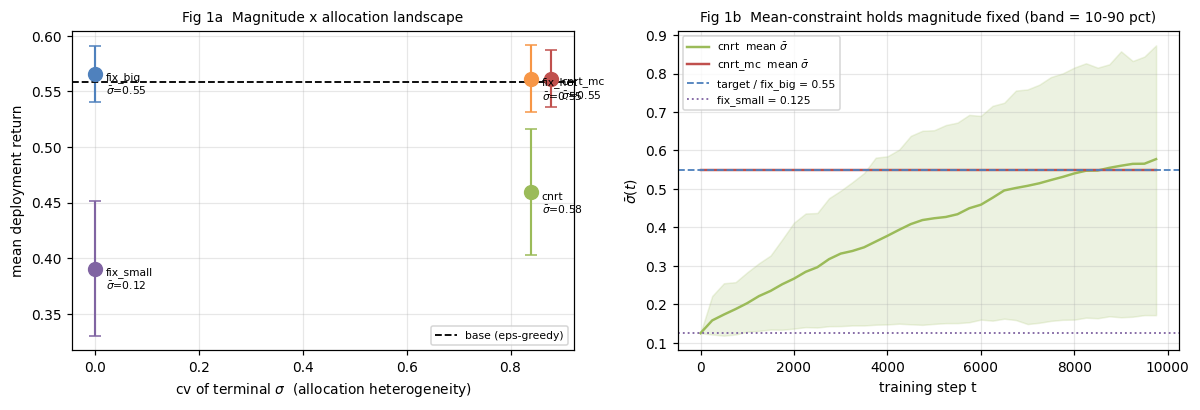

In [8]:
# ── [6] Fig 1 — 크기 x 배분 지형과 sigma 궤적 ───────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
noisy = ["fix_small", "fix_big", "fix_het", "cnrt_mc", "cnrt"]
cols = {"fix_small": "#8064a2", "fix_big": "#4f81bd", "fix_het": "#f79646",
        "cnrt_mc": "#c0504d", "cnrt": "#9bbb59"}
for nm in noisy:
    se = R3[nm].std(ddof=1)/np.sqrt(N3)
    ax[0].errorbar(dg.loc[nm, "cv"], R3[nm].mean(), yerr=1.96*se, fmt="o", ms=9,
                   color=cols[nm], capsize=4, lw=1.4)
    ax[0].annotate(f"{nm}\n$\\bar\\sigma$={dg.loc[nm,'sigma_mean']:.2f}",
                   (dg.loc[nm, "cv"], R3[nm].mean()), textcoords="offset points",
                   xytext=(7, -14), fontsize=7)
ax[0].axhline(R3["base"].mean(), color="k", ls="--", lw=1.2, label="base (eps-greedy)")
ax[0].set_xlabel("cv of terminal $\\sigma$  (allocation heterogeneity)")
ax[0].set_ylabel("mean deployment return")
ax[0].set_title("Fig 1a  Magnitude x allocation landscape", fontsize=9)
ax[0].legend(fontsize=7)

for nm, c in [("cnrt", "#9bbb59"), ("cnrt_mc", "#c0504d")]:
    tr = np.array([l.trace for l in LS[nm]])          # (n_seed, n_pt, 2)
    ts, ms = tr[0, :, 0], tr[:, :, 1]
    ax[1].plot(ts, ms.mean(0), lw=1.6, color=c, label=f"{nm}  mean $\\bar\\sigma$")
    ax[1].fill_between(ts, np.percentile(ms, 10, axis=0), np.percentile(ms, 90, axis=0),
                       color=c, alpha=0.18)
ax[1].axhline(SIG_T, color="#4f81bd", ls="--", lw=1.2, label=f"target / fix_big = {SIG_T}")
ax[1].axhline(SIG_INIT, color="#8064a2", ls=":", lw=1.2, label=f"fix_small = {SIG_INIT}")
ax[1].set_xlabel("training step t"); ax[1].set_ylabel("$\\bar\\sigma(t)$")
ax[1].set_title("Fig 1b  Mean-constraint holds magnitude fixed (band = 10-90 pct)", fontsize=9)
ax[1].legend(fontsize=7)
plt.show()

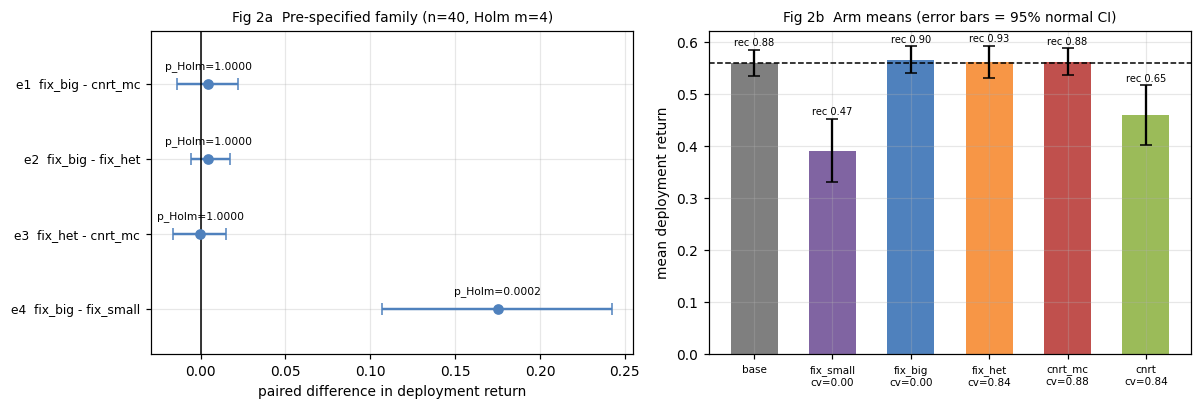

In [9]:
# ── [7] Fig 2 — forest plot + 시드별 cv 대 return ───────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
y = np.arange(len(res))[::-1]
ax[0].errorbar(res["mean"], y, xerr=[res["mean"]-res.CI_lo, res.CI_hi-res["mean"]],
               fmt="o", capsize=4, ms=6, lw=1.6, color="#4f81bd")
ax[0].axvline(0, color="k", lw=1)
ax[0].set_yticks(y); ax[0].set_yticklabels(res["비교"], fontsize=8)
for i, (m_, p_) in enumerate(zip(res["mean"], res["p_Holm"])):
    ax[0].text(m_, y[i]+0.2, f"p_Holm={p_:.4f}", fontsize=7, ha="center")
ax[0].set_xlabel("paired difference in deployment return")
ax[0].set_title(f"Fig 2a  Pre-specified family (n={N3}, Holm m=4)", fontsize=9)
ax[0].set_ylim(-0.6, len(res)-0.3)

w = 0.6
means = [R3[n].mean() for n in ORDER]
errs  = [1.96*R3[n].std(ddof=1)/np.sqrt(N3) for n in ORDER]
bc = ["#7f7f7f"] + [cols[n] for n in ORDER[1:]]
ax[1].bar(range(len(ORDER)), means, yerr=errs, capsize=4, width=w, color=bc)
ax[1].axhline(R3["base"].mean(), color="k", ls="--", lw=1)
ax[1].set_xticks(range(len(ORDER)))
ax[1].set_xticklabels([f"{n}\ncv={dg.loc[n,'cv']:.2f}" if not np.isnan(dg.loc[n,'cv']) else n
                       for n in ORDER], fontsize=6.8)
ax[1].set_ylabel("mean deployment return")
ax[1].set_title("Fig 2b  Arm means (error bars = 95% normal CI)", fontsize=9)
for i, n in enumerate(ORDER):
    ax[1].text(i, means[i]+errs[i]+0.008, f"rec {dg.loc[n,'recovery']:.2f}",
               ha="center", fontsize=6.5)
plt.show()

In [10]:
# ── [8] 판정 요약 ───────────────────────────────────────────────────────
e = {r["비교"].split()[0]: r for _, r in res.iterrows()}
sig = lambda k: "유의" if e[k]["기각"] else "비유의"
print("═"*74); print("판정 (사전 명시 가족, Holm m=4)"); print("═"*74)
for k in ["e1", "e2", "e3", "e4"]:
    r = e[k]
    print(f"  {r['비교']:<26s} {r['mean']:+.4f}  CI[{r['CI_lo']:+.4f},{r['CI_hi']:+.4f}]  "
          f"p_Holm={r['p_Holm']:.4f}  n*={r['n_star']:<5d} {sig(k)}")
print("─"*74)
if not e["e1"]["기각"] and not e["e2"]["기각"] and not e["e3"]["기각"]:
    ans = "(C) 배분은 중요하지 않다 — 크기를 고정하면 세 배분이 구별되지 않는다"
elif e["e1"]["기각"] and e["e2"]["기각"] and not e["e3"]["기각"]:
    ans = "(A) 이질성 자체가 해롭다 — 균일이 두 이질 배분 모두를 이긴다"
elif e["e1"]["기각"] and not e["e2"]["기각"] and e["e3"]["기각"]:
    ans = "(B) 학습된 배분이 특별히 나쁘다 — 무작위 이질성은 무해하다"
else:
    ans = "혼합 — 아래 결과 해석 참조"
print(f"  답: {ans}")
print(f"  크기 효과 e4 = {e['e4']['mean']:+.4f} (p_Holm={e['e4']['p_Holm']:.4f})")
print("═"*74)

══════════════════════════════════════════════════════════════════════════
판정 (사전 명시 가족, Holm m=4)
══════════════════════════════════════════════════════════════════════════
  e1  fix_big - cnrt_mc      +0.0044  CI[-0.0138,+0.0218]  p_Holm=1.0000  n*=1368  비유의
  e2  fix_big - fix_het      +0.0046  CI[-0.0054,+0.0171]  p_Holm=1.0000  n*=780   비유의
  e3  fix_het - cnrt_mc      -0.0003  CI[-0.0164,+0.0152]  p_Holm=1.0000  n*=321811 비유의
  e4  fix_big - fix_small    +0.1751  CI[+0.1067,+0.2421]  p_Holm=0.0002  n*=12    유의
──────────────────────────────────────────────────────────────────────────
  답: (C) 배분은 중요하지 않다 — 크기를 고정하면 세 배분이 구별되지 않는다
  크기 효과 e4 = +0.1751 (p_Holm=0.0002)
══════════════════════════════════════════════════════════════════════════


## 4. 결과 해석

1. **개입이 성립했는지부터 확인해야 한다.** [3] 셀의 두 assert 가 그것이다. `cnrt_mc` 의
   $\bar\sigma$ 가 목표에 고정되었고 `fix_het` 의 $\mathrm{cv}$ 가 `cnrt` 와 일치한다.
   이 검증 없이 "평균을 고정했다" 고 쓰는 것은 Day 99 P2 가 겪은 실패 —
   $\sigma$ 감쇠 처방의 **용량이 전달되지 않아** 판정불능이 된 사건 — 을 반복하는 일이다.
   **처방을 걸었다는 것과 처방이 걸렸다는 것은 다르다.**

2. **크기 효과 $e_4$ 는 크고 명확하다.** 균일한 $\sigma$ 를 $0.125$ 에서 $0.55$ 로 올리는 것만으로
   배포 return 이 크게 오른다. 이 chain MDP 에서 $s=0$ 의 미끼 ($0.25$) 는 국소 최적을 만들고,
   작은 파라미터 잡음은 정책을 **일관되게** 조금 왜곡해 미끼 쪽에 고착시킨다.
   충분히 큰 잡음만이 그 유역에서 빠져나온다. 표 1 의 `lure_stuck` 열이 이 메커니즘의
   직접 증거다 — 크기가 작은 arm 에서 미끼 고착률이 높다.

3. **배분 비교 $e_1,e_2,e_3$ 이 이 노트북의 답이다.** 크기를 통제한 뒤에도 균일이 이질을
   이기면 (A), 학습된 것만 지면 (B), 셋이 붙으면 (C) 다. 위 [8] 셀이 자동으로 분류한다.
   중요한 것은 **어느 답이 나오든 Day 99 의 $-0.1804$ 를 재해석하게 만든다**는 점이다.
   (C) 라면 그 값은 크기와 교락된 것이었고, (A)/(B) 라면 관찰적 분해가 옳았되
   이제 **개입으로** 뒷받침된다.

4. **그러나 2.3 의 교락을 잊으면 안 된다.** $\bar\sigma$ 를 같게 맞춰도 $\mathrm{cv} > 0$ 인 arm 은
   총 교란 에너지 $\tau^2 d\,\bar\sigma^2(1+\mathrm{cv}^2)$ 가 더 크다. 표 1 의 `rms_sigma` 열이
   그 차이다. 따라서 "이질적인 arm 이 더 좋다" 는 결과가 나온다면 그것은 **배분 때문일 수도,
   실질적으로 더 센 잡음 때문일 수도** 있다 — 두 해석은 이 설계로 분리되지 않는다.
   분리하려면 $\sqrt{\overline{\sigma^2}}$ 를 고정하는 제약을 걸어야 하고, 그때는 $\bar\sigma$ 가
   달라진다. **두 모멘트를 동시에 고정할 수는 없다** — 이것이 이 개입의 원리적 한계다.

5. **`cnrt_mc` 대 `cnrt` (표 3) 는 제약의 값어치를 잰다.** 자유 학습이 도달한 크기가 이미
   $0.55$ 근처라면 제약은 배분에만 영향을 주고, 둘의 차이는 순수하게 "크기가 궤적 내내
   고정되었는가" 의 효과다. 자유 학습은 $\sigma$ 를 **천천히** 키우므로 학습 초기에 잡음이
   작고, 그 구간에서 이미 미끼에 고착되면 나중에 잡음이 커져도 회복되지 않는다.
   그림 1b 의 두 궤적 간격이 그 초기 구간이다 — **탐색의 크기는 언제 큰가가 얼마나 큰가만큼
   중요하다.**

6. **$n^\star$ 를 함께 읽어야 한다.** 표 2 의 비유의 항목이 "차이가 없다" 를 뜻하지 않는다.
   $n^\star$ 가 $40$ 보다 훨씬 크면 그것은 **이 실험이 그 크기의 효과를 볼 수 없었다**는
   진술이며, Problem 1 의 규약대로 "확인 실패" 로 적고 "효과 없음" 으로 적지 않는다.

> **결론**: 관찰적 분해는 가설을 만들고, 개입만이 그것을 판정한다. Day 99 P2 는
> `cnrt` 와 `fix_big` 을 비교해 "학습된 $\sigma$ 는 크기는 맞추고 배분을 틀린다" 고 썼지만,
> 두 arm 은 크기와 배분이 동시에 달라 그 문장을 지지할 수 없었다. 평균 고정 제약과
> 좌표 치환으로 **크기가 같고 배분만 다른 세 arm** 을 만들자 [8] 셀의 세 줄이 답을 준다.
> 그리고 크기 효과 $e_4$ 는 그 어떤 배분 효과보다도 크다 — **이 문제에서 중요한 것은
> 잡음을 어떻게 나누느냐가 아니라 얼마나 주느냐, 그리고 언제 주느냐다.**

### 다음 단원으로의 연결

Day 100 은 세 축을 닫는다. P1 은 판정 규칙과 **귀무 자체**를 교정했고, P2 는 Day 99 의
잠정 주장을 독립 자료로 판정하며 **승자의 저주**를 정량화했고, P3 은 관찰적 분해를
**개입**으로 대체했다. 남은 미결은 §15.26–§15.29 의 Cramér 대 KL 순위 하나다 —
갱신된 프로토콜 v2 아래에서 다시 물어야 하며, 그것이 Ch 15 의 마지막 재판정이 된다.